In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
PROJECT_ROOT

PosixPath('/Users/sahil/Group Studies/Quantization-Group-Studies')

## Load Model

In [2]:
from src.models import RESNET18_IMAGENET_PRESET, load_pretrained_resnet18

print(f"Loading preset: {RESNET18_IMAGENET_PRESET}")
model = load_pretrained_resnet18()
model.summary()

/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading preset: resnet_18_imagenet


Preprocessor: "res_net_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ res_net_image_converter (ResNetImageConverter)                │                   Image size: (224, 224) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "res_net_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)                      │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ res_net_backbone (ResNetBackbone)             │ (None, None, None, 512)            │          11,186,112 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ pooler (GlobalAveragePooling2D)               │ (None, 512)                        │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ output_dropout (Dropout)                      │ (None, 512)                        │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ predictions (Dense)                           │ (None, 1000)                       │             513,000 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 11,699,112 (44.63 MB)

 Trainable params: 11,689,512 (44.59 MB)

 Non-trainable params: 9,600 (37.50 KB)

## Basic Inference Check

In [3]:
import numpy as np

sample_batch = np.zeros((1, 224, 224, 3), dtype=np.uint8)
predictions = model.predict(sample_batch)

predictions.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


(1, 1000)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

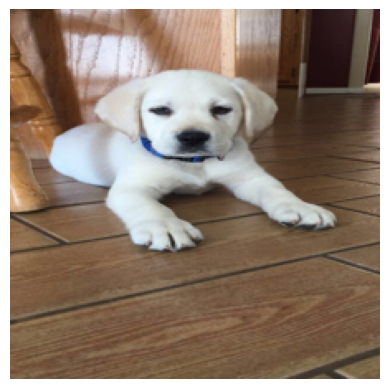

In [6]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path = PROJECT_ROOT / "data" / "sample.jpg"

image = Image.open(image_path).convert("RGB")
image_resized = image.resize((224, 224))

plt.imshow(image_resized)
plt.axis("off")

In [7]:
from tensorflow.keras.applications.imagenet_utils import decode_predictions

x = np.array(image_resized, dtype=np.uint8)
x = np.expand_dims(x, axis=0)

predictions = model.predict(x)

predictions.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


(1, 1000)

In [8]:
top_index = predictions[0].argmax()
top_score = predictions[0][top_index]

top_index, top_score

(np.int64(208), np.float32(2.6471736))

In [9]:
import tensorflow as tf

probabilities = tf.nn.softmax(predictions[0]).numpy()

top_index = probabilities.argmax()
top_probability = probabilities[top_index]

top_index, top_probability

(np.int64(208), np.float32(0.9624379))

In [11]:
x = np.array(image_resized, dtype=np.uint8)
x = np.expand_dims(x, axis=0)

predictions = model.predict(x)

probabilities = tf.nn.softmax(predictions).numpy()
decoded = decode_predictions(probabilities, top=5)

for imagenet_id, label, score in decoded[0]:
    print(f"{label}: {score:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Labrador_retriever: 0.9624
golden_retriever: 0.0067
kuvasz: 0.0063
dalmatian: 0.0025
beagle: 0.0022
